In [1]:
import tensorflow as tf
from keras.src.layers import Dropout
from tensorflow.keras import layers
import tensorboard as tb
import pandas as pd
import numpy as np
import datetime as dt
from sklearn.preprocessing import MinMaxScaler

print("TensorFlow version: ", tf.__version__)

pjm_hourly_est = pd.read_csv('electricity-data/pjm_hourly_est.csv')

print(pjm_hourly_est.head())


TensorFlow version:  2.20.0
              Datetime  AEP  COMED  DAYTON  DEOK  DOM  DUQ  EKPC  FE  NI  \
0  1998-12-31 01:00:00  NaN    NaN     NaN   NaN  NaN  NaN   NaN NaN NaN   
1  1998-12-31 02:00:00  NaN    NaN     NaN   NaN  NaN  NaN   NaN NaN NaN   
2  1998-12-31 03:00:00  NaN    NaN     NaN   NaN  NaN  NaN   NaN NaN NaN   
3  1998-12-31 04:00:00  NaN    NaN     NaN   NaN  NaN  NaN   NaN NaN NaN   
4  1998-12-31 05:00:00  NaN    NaN     NaN   NaN  NaN  NaN   NaN NaN NaN   

   PJME  PJMW  PJM_Load  
0   NaN   NaN   29309.0  
1   NaN   NaN   28236.0  
2   NaN   NaN   27692.0  
3   NaN   NaN   27596.0  
4   NaN   NaN   27888.0  


In [ ]:
#create test dataset, convert NA values to 0, and sum across rows
test_data = pjm_hourly_est.copy()
numeric_cols = test_data.select_dtypes(include=[np.number]).columns

test_data[numeric_cols] = test_data[numeric_cols].fillna(0)
test_data['total_usage'] = test_data[numeric_cols].sum(axis=1, skipna=True)

test_data = test_data[['Datetime', 'total_usage']]

print(test_data.head())

In [ ]:
#convert string Datetime to datetime object
print(test_data.dtypes)

format_string = "%Y-%m-%d %H:%M:%S"

test_data['Datetime'] = pd.to_datetime(test_data['Datetime'], format='%Y-%m-%d %H:%M:%S')

print(test_data.dtypes)

In [9]:
#create modified dataset with offset sinusoidal waves for date and time

input_scaler = MinMaxScaler(feature_range=(-1, 1))
output_scaler = MinMaxScaler(feature_range=(0,1))

data_mod = test_data.copy()
data_mod['year'] = data_mod['Datetime'].dt.year
data_mod['day_of_year'] = data_mod['Datetime'].dt.dayofyear
data_mod['time_of_day'] = data_mod['Datetime'].dt.hour

data_mod['year_scaled'] = input_scaler.fit_transform(data_mod[['year']])

data_mod['day_SIN'] = np.sin((2 * np.pi * data_mod['day_of_year']) / 365)
data_mod['day_COS'] = np.cos((2 * np.pi * data_mod['day_of_year']) / 365)
data_mod['time_SIN'] = np.sin((2 * np.pi * data_mod['time_of_day']) / 24)
data_mod['time_COS'] = np.cos((2 * np.pi * data_mod['time_of_day']) / 24)

data_mod['total_usage_scaled'] = output_scaler.fit_transform(data_mod[['total_usage']])

data_mod = data_mod.sort_values('Datetime')

#copy modified data to df
df = data_mod.copy()

print(df.head())

                Datetime  total_usage  year  day_of_year  time_of_day  \
6574 1998-04-01 01:00:00      22259.0  1998           91            1   
6575 1998-04-01 02:00:00      21244.0  1998           91            2   
6576 1998-04-01 03:00:00      20651.0  1998           91            3   
6577 1998-04-01 04:00:00      20421.0  1998           91            4   
6578 1998-04-01 05:00:00      20713.0  1998           91            5   

      year_scaled   day_SIN   day_COS  time_SIN  time_COS  total_usage_scaled  
6574         -1.0  0.999991  0.004304  0.258819  0.965926            0.034123  
6575         -1.0  0.999991  0.004304  0.500000  0.866025            0.026904  
6576         -1.0  0.999991  0.004304  0.707107  0.707107            0.022687  
6577         -1.0  0.999991  0.004304  0.866025  0.500000            0.021051  
6578         -1.0  0.999991  0.004304  0.965926  0.258819            0.023128  


In [10]:
feature_cols = ['year_scaled', 'day_SIN', 'day_COS', 'time_SIN', 'time_COS']
target_col = 'total_usage_scaled'

#first 80% of data is training, last 20% is testing
split_index = int(len(df) * 0.8)

train_df = df.iloc[:split_index]
test_df = df.iloc[split_index:]

print(f"Train range: {train_df['Datetime'].min()} to {train_df['Datetime'].max()}")
print(f"Test range: {test_df['Datetime'].min()} to {test_df['Datetime'].max()}")

Train range: 1998-04-01 01:00:00 to 2014-07-09 11:00:00
Test range: 2014-07-09 12:00:00 to 2018-08-03 00:00:00


In [11]:
#function to create sequences for the LSTM to interpret
def create_sequences(data, target, window_size):
    x, y = [], []
    for i in range(len(data) - window_size):
        x.append(data[i:(i + window_size)])
        y.append(target[i + window_size])
    return np.array(x), np.array(y)

In [12]:
WINDOW_SIZE = 24;

X_train, y_train = create_sequences(
    train_df[feature_cols].values,
    train_df[target_col].values,
    WINDOW_SIZE
)

X_test, y_test = create_sequences(
    test_df[feature_cols].values,
    test_df[target_col].values,
    WINDOW_SIZE
)

#check to make sure X_train shape is ([num_samples], 24, 5)
print("X_train shape:", X_train.shape)

X_train shape: (142585, 24, 5)


In [13]:
BATCH_SIZE = 32

train_dataset = tf.data.Dataset.from_tensor_slices((X_train, y_train))
train_dataset = train_dataset.cache().shuffle(1000).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

test_dataset = tf.data.Dataset.from_tensor_slices((X_test, y_test))
test_dataset = test_dataset.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

In [14]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Input, Dropout

model = Sequential([
    Input(shape = (24,5)),

    LSTM(BATCH_SIZE, activation='tanh'),

    Dropout(0.2),

    Dense(1),
])

model.compile(
    optimizer='adam',
    loss='mse',      # Mean Squared Error
    metrics=['mae']  # Mean Absolute Error
)

In [15]:
EPOCHS = 10

history = model.fit(
    train_dataset,
    epochs=EPOCHS,
    validation_data=test_dataset,
    verbose=1
)

Epoch 1/10
4456/4456 ━━━━━━━━━━━━━━━━━━━━ 11s 2ms/step - loss: 0.0028 - mae: 0.0393 - val_loss: 0.0059 - val_mae: 0.0589
Epoch 2/10
4456/4456 ━━━━━━━━━━━━━━━━━━━━ 10s 2ms/step - loss: 0.0031 - mae: 0.0406 - val_loss: 0.0072 - val_mae: 0.0653
Epoch 3/10
4456/4456 ━━━━━━━━━━━━━━━━━━━━ 10s 2ms/step - loss: 0.0029 - mae: 0.0401 - val_loss: 0.0074 - val_mae: 0.0664
Epoch 4/10
4456/4456 ━━━━━━━━━━━━━━━━━━━━ 10s 2ms/step - loss: 0.0029 - mae: 0.0397 - val_loss: 0.0067 - val_mae: 0.0639
Epoch 5/10
4456/4456 ━━━━━━━━━━━━━━━━━━━━ 10s 2ms/step - loss: 0.0028 - mae: 0.0396 - val_loss: 0.0079 - val_mae: 0.0694
Epoch 6/10
4456/4456 ━━━━━━━━━━━━━━━━━━━━ 10s 2ms/step - loss: 0.0028 - mae: 0.0394 - val_loss: 0.0066 - val_mae: 0.0624
Epoch 7/10
4456/4456 ━━━━━━━━━━━━━━━━━━━━ 10s 2ms/step - loss: 0.0028 - mae: 0.0392 - val_loss: 0.0078 - val_mae: 0.0690
Epoch 8/10
4456/4456 ━━━━━━━━━━━━━━━━━━━━ 10s 2ms/step - loss: 0.0027 - mae: 0.0388 - val_loss: 0.0082 - val_mae: 0.0709
Epoch 9/10
4456/4456 ━━━━━━━━━━━

In [16]:
predictions_scaled = model.predict(test_dataset)

predictions_mw = output_scaler.inverse_transform(predictions_scaled)

y_test_mw = output_scaler.inverse_transform(y_test.reshape(-1, 1))

1114/1114 ━━━━━━━━━━━━━━━━━━━━ 1s 743us/step


In [17]:
preds_pd = pd.DataFrame(predictions_mw)
test_pd = pd.DataFrame(y_test_mw)
pred_vs_test = pd.concat([preds_pd, test_pd], axis = 1)
pred_vs_test.columns = ['Predicted', 'Actual']
print(pred_vs_test.head())

print(f"First Prediction: {predictions_mw[0][0]:.2f} MW")
print(f"Actual Usage: {y_test_mw[0][0]:.2f} MW")

       Predicted    Actual
0  113781.210938  109235.0
1  117918.414062  112689.0
2  121167.539062  116034.0
3  123511.843750  118041.0
4  124870.476562  119372.0
First Prediction: 113781.21 MW
Actual Usage: 109235.00 MW


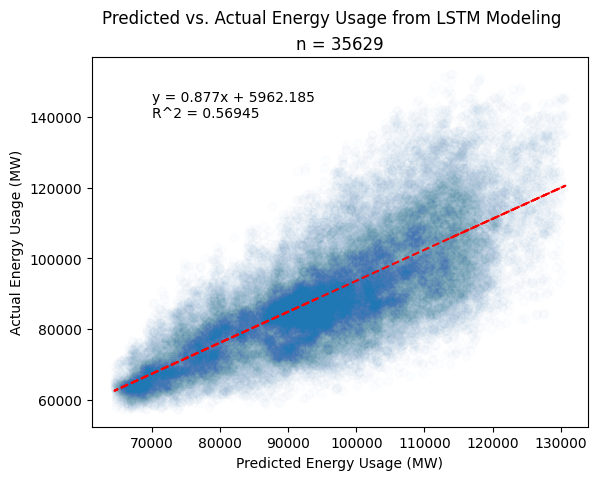

In [19]:
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score

x = pred_vs_test['Predicted']
y = pred_vs_test['Actual']
n = len(pred_vs_test)

#COPIED OVER: get r^2 for prediction and actual
z = np.polyfit(x, y, 1)
p = np.poly1d(z)
y_pred = p(x)
r_squared = r2_score(y, y_pred)
#print(r_squared)
#print(z[0],z[1])


plt.scatter(x,y, alpha=0.01)
plt.plot(x,p(x),"r--")
plt.text(70000,140000,"y = %.3fx + %.3f\nR^2 = %.5f"%(z[0],z[1],r_squared))

plt.suptitle("Predicted vs. Actual Energy Usage from LSTM Modeling")
plt.title("n = %d"%(n))
plt.xlabel("Predicted Energy Usage (MW)")
plt.ylabel("Actual Energy Usage (MW)")
plt.show()